#PROJETO A SAFRA ANTES DA COLHEITA: DA PARA PREVER A PRODUTIVIDADE DA SOJA SÓ COM DADOS PUBLICOS?

In [25]:
#Importando bibliotecas
import sidrapy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import theilslopes
import geobr
import geopandas as gpd
from matplotlib.patches import Patch




#Importando a tabela 5457 do SIDRA (SITE IBGE) com os dados de produção de soja no estado de São Paulo nos últimos 12 anos
dados_soja = sidrapy.get_table(
    table_code="5457",
    territorial_level="6",
    ibge_territorial_code="in n3 35",
    variable="112,216",
    classifications= {"782": "40124"},
    period="last 12"
)

In [26]:
#Verificar colunas do dataframe
dados_soja.columns

Index(['NC', 'NN', 'MC', 'MN', 'V', 'D1C', 'D1N', 'D2C', 'D2N', 'D3C', 'D3N',
       'D4C', 'D4N'],
      dtype='str')

In [27]:
#Verificando o dataframe
dados_soja.head()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Município (Código),Município,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias e permanentes...,Produto das lavouras temporárias e permanentes
1,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2014,2014,112,Rendimento médio da produção,40124,Soja (em grão)
2,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2014,2014,216,Área colhida,40124,Soja (em grão)
3,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2015,2015,112,Rendimento médio da produção,40124,Soja (em grão)
4,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2015,2015,216,Área colhida,40124,Soja (em grão)


In [28]:
#Mostrando as ultimas linhas do dataframe
dados_soja.tail()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
15404,6,Município,1006,Hectares,400,3557303,Estiva Gerbi - SP,2023,2023,216,Área colhida,40124,Soja (em grão)
15405,6,Município,33,Quilogramas por Hectare,3900,3557303,Estiva Gerbi - SP,2024,2024,112,Rendimento médio da produção,40124,Soja (em grão)
15406,6,Município,1006,Hectares,500,3557303,Estiva Gerbi - SP,2024,2024,216,Área colhida,40124,Soja (em grão)
15407,6,Município,33,Quilogramas por Hectare,3900,3557303,Estiva Gerbi - SP,2025,2025,112,Rendimento médio da produção,40124,Soja (em grão)
15408,6,Município,1006,Hectares,520,3557303,Estiva Gerbi - SP,2025,2025,216,Área colhida,40124,Soja (em grão)


In [29]:
#Verificando os dados gerais do dataframe
dados_soja.info()

<class 'pandas.DataFrame'>
RangeIndex: 15409 entries, 0 to 15408
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   NC      15409 non-null  str  
 1   NN      15409 non-null  str  
 2   MC      15409 non-null  str  
 3   MN      15409 non-null  str  
 4   V       15409 non-null  str  
 5   D1C     15409 non-null  str  
 6   D1N     15409 non-null  str  
 7   D2C     15409 non-null  str  
 8   D2N     15409 non-null  str  
 9   D3C     15409 non-null  str  
 10  D3N     15409 non-null  str  
 11  D4C     15409 non-null  str  
 12  D4N     15409 non-null  str  
dtypes: str(13)
memory usage: 3.1 MB


In [30]:
#Renomeando as colunas do dataframe para facilitar a manipulação dos dados
dados_soja.rename(columns={"NC": "Nível Territorial (Código)", "NN": "Nível Territorial (Nome)", "MC": "Unidade de Medida (Código)", "MN": "Unidade de Medida (Nome)", "V": "Valor", "D1C": "Municipio (Código)", "D1N": "Municipio", "D2C": "Ano Codigo", "D2N": "Ano", "D3C": "Variavel Codigo", "D3N": "Variavel", "D4N": "Cultura"}, inplace=True)

#Excluindo a primeira linha da planilha
dados_soja = dados_soja.drop(0)

dados_soja.head()

,Nível Territorial (Código),Nível Territorial (Nome),Unidade de Medida (Código),Unidade de Medida (Nome),Valor,Municipio (Código),Municipio,Ano Codigo,Ano,Variavel Codigo,Variavel,D4C,Cultura
1,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2014,2014,112,Rendimento médio da produção,40124,Soja (em grão)
2,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2014,2014,216,Área colhida,40124,Soja (em grão)
3,6,Município,33,Quilogramas por Hectare,-,3500105,Adamantina - SP,2015,2015,112,Rendimento médio da produção,40124,Soja (em grão)
4,6,Município,1006,Hectares,-,3500105,Adamantina - SP,2015,2015,216,Área colhida,40124,Soja (em grão)
5,6,Município,33,Quilogramas por Hectare,1800,3500105,Adamantina - SP,2016,2016,112,Rendimento médio da produção,40124,Soja (em grão)


In [31]:
#Verificando e excluindo duplicados
dados_soja.duplicated().sum()


np.int64(0)

In [32]:
#Alterando valores nulos para 0
dados_soja = dados_soja.fillna(0)

In [33]:
#Converter valores e colocar as variaves lado a lado

base_soja = dados_soja.copy()

base_soja["Valor"] = pd.to_numeric(base_soja["Valor"], errors="coerce")
base_soja["Ano"] = base_soja["Ano"].astype(int)
base_soja["Variavel Codigo"] = base_soja["Variavel Codigo"].astype(str)


#Uma linha por municipio-ano, com rendimento (112) e area colhida (216)

base = (
    base_soja.pivot_table(
        index=["Municipio (Código)","Municipio","Ano"],
        columns="Variavel Codigo",
        values="Valor",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"112": "rendimento_kg_ha", "216": "area_colhida_ha"})

)

base.columns.name = None

#Mantem só municipio e ano que efetivamente colheu soja

base = base[(base["rendimento_kg_ha"] > 0) & (base["area_colhida_ha"] > 0)].copy()


In [34]:
#Produtividade estadual por ano(ponderada pela área colhida)

# Média simples trataria um município de 50 ha igual a um de 50.000 ha.
# A média ponderada pela área = produção total / área total (visão do estado).

base["producao_total_kg"] = base["rendimento_kg_ha"] * base["area_colhida_ha"]

estadual = base.groupby("Ano").agg(
    area_colhida_ha=("area_colhida_ha", "sum"),
    producao_total_kg=("producao_total_kg", "sum"),
    rend_media_simples_kg_ha=("rendimento_kg_ha", "mean"),
    n_municipios=("Municipio (Código)", "nunique"),
)

estadual["rend_kg_ha"] = estadual["producao_total_kg"] / estadual["area_colhida_ha"]
estadual["rend_sc_ha"] = estadual["rend_kg_ha"] / 60

In [35]:
#Ganho Tecnológico:tendencia robusta (Theil-Sen) da produtividade estadual (kg/ha) ao longo do tempo

anos = estadual.index.values
y = estadual["rend_kg_ha"].values

slope, intercept, slope_lo, slope_hi = theilslopes(y, anos, 0.95)
slope_ols, intercept_ols = np.polyfit(anos, y, 1)  #para comparar

estadual["tendencia_kg_ha"] = intercept + slope * anos
estadual["tendencia_sc_ha"] = estadual["tendencia_kg_ha"] / 60

ganho_pct_ano = slope/ estadual["tendencia_kg_ha"].mean() * 100


In [36]:
#Anos de quebra: desvio em relação à tendencia

LIMIAR_QUEBRA_PCT = -10   # ano X% abaixo da tendência = quebra (ajustável)
LIMIAR_Z = -1.5           # ou desvio robusto muito abaixo do normal
 
estadual["residuo_kg_ha"] = y - estadual["tendencia_kg_ha"]
estadual["desvio_pct"] = (y / estadual["tendencia_kg_ha"] - 1) * 100
 
# Desvio-padrão robusto dos resíduos (MAD), menos sensível às próprias quebras
res = estadual["residuo_kg_ha"]
sigma_robusto = 1.4826 * np.median(np.abs(res - np.median(res)))
estadual["z_robusto"] = res / sigma_robusto if sigma_robusto > 0 else 0.0
 
estadual["quebra"] = (estadual["desvio_pct"] <= LIMIAR_QUEBRA_PCT) | (
    estadual["z_robusto"] <= LIMIAR_Z
)

In [37]:
# Resumo
print("=" * 70)
print("PRODUTIVIDADE DE SOJA — ESTADO DE SÃO PAULO")
print("=" * 70)
print(f"Período: {anos.min()}–{anos.max()}")
print(
    f"Ganho tecnológico (Theil-Sen): {slope:+.1f} kg/ha/ano "
    f"({slope / 60:+.2f} sc/ha/ano | {ganho_pct_ano:+.2f}% ao ano)"
)
print(
    f"IC 95% da inclinação: {slope_lo:+.1f} a {slope_hi:+.1f} kg/ha/ano"
)
print(f"Comparação — regressão linear (OLS): {slope_ols:+.1f} kg/ha/ano")
print(f"Anos de quebra: {list(estadual.index[estadual['quebra']]) or 'nenhum'}")
print()
 
tabela = estadual[
    ["n_municipios", "area_colhida_ha", "rend_kg_ha", "rend_sc_ha",
     "tendencia_sc_ha", "desvio_pct", "z_robusto", "quebra"]
].round(2)
display(tabela) if "display" in dir(__builtins__) or "get_ipython" in globals() else print(tabela)
 


PRODUTIVIDADE DE SOJA — ESTADO DE SÃO PAULO
Período: 2014–2025
Ganho tecnológico (Theil-Sen): +40.0 kg/ha/ano (+0.67 sc/ha/ano | +1.16% ao ano)
IC 95% da inclinação: -5.2 a +107.2 kg/ha/ano
Comparação — regressão linear (OLS): +37.0 kg/ha/ano
Anos de quebra: [2014, 2024]



,n_municipios,area_colhida_ha,rend_kg_ha,rend_sc_ha,tendencia_sc_ha,desvio_pct,z_robusto,quebra
Ano,,,,,,,,
2014,300,692589.0,2467.89,41.13,53.58,-23.24,-3.34,True
2015,320,791903.0,3038.53,50.64,54.25,-6.65,-0.97,False
2016,364,848782.0,3290.32,54.84,54.91,-0.14,-0.02,False
2017,395,946540.0,3477.78,57.96,55.58,4.29,0.64,False
2018,405,973064.0,3504.72,58.41,56.25,3.85,0.58,False
2019,432,1080336.0,3198.56,53.31,56.91,-6.33,-0.97,False
2020,441,1132955.0,3431.30,57.19,57.58,-0.68,-0.11,False
2021,464,1199351.0,3489.20,58.15,58.25,-0.16,-0.03,False
2022,470,1252070.0,3576.50,59.61,58.91,1.18,0.19,False


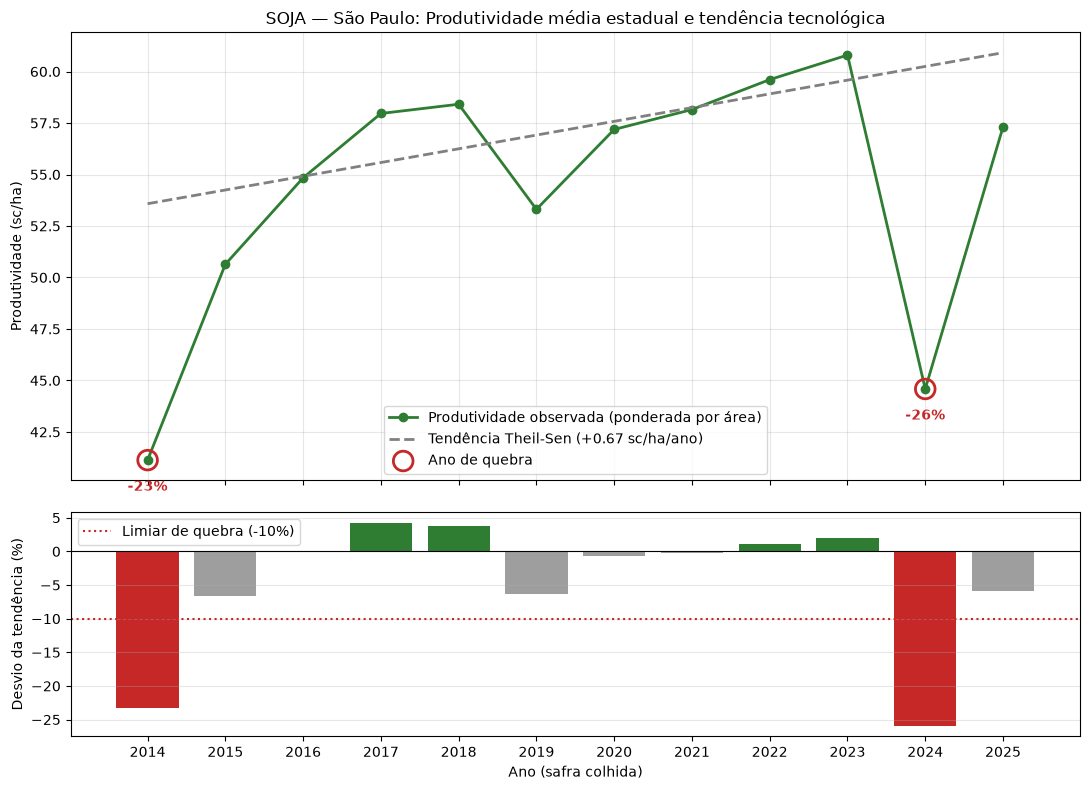

In [38]:
#Gráficos

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
 
# 6.1 Produtividade observada x tendência
ax1.plot(anos, estadual["rend_sc_ha"], "o-", color="#2E7D32", lw=2,
         label="Produtividade observada (ponderada por área)")
ax1.plot(anos, estadual["tendencia_sc_ha"], "--", color="gray", lw=2,
         label=f"Tendência Theil-Sen ({slope / 60:+.2f} sc/ha/ano)")
 
q = estadual[estadual["quebra"]]
ax1.scatter(q.index, q["rend_sc_ha"], s=200, facecolors="none",
            edgecolors="#C62828", linewidths=2, zorder=5, label="Ano de quebra")
for ano, row in q.iterrows():
    ax1.annotate(f"{row['desvio_pct']:.0f}%", (ano, row["rend_sc_ha"]),
                 textcoords="offset points", xytext=(0, -22), ha="center",
                 color="#C62828", fontweight="bold")
 
ax1.set_ylabel("Produtividade (sc/ha)")
ax1.set_title("SOJA — São Paulo: Produtividade média estadual e tendência tecnológica")
ax1.legend(loc="best")
ax1.grid(alpha=0.3)
 
# 6.2 Desvio em relação à tendência
cores = np.where(estadual["quebra"], "#C62828",
                 np.where(estadual["desvio_pct"] >= 0, "#2E7D32", "#9E9E9E"))
ax2.bar(anos, estadual["desvio_pct"], color=cores)
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(LIMIAR_QUEBRA_PCT, color="#C62828", ls=":",
            label=f"Limiar de quebra ({LIMIAR_QUEBRA_PCT}%)")
ax2.set_ylabel("Desvio da tendência (%)")
ax2.set_xlabel("Ano (safra colhida)")
ax2.set_xticks(anos)
ax2.legend(loc="best")
ax2.grid(alpha=0.3, axis="y")
 
plt.tight_layout()
plt.show()
 

In [39]:
#Realizar o mapa de produtividade média por periodo, com malha do geobr
# Média ponderada pela área (produção total / área total do período):
# um ano com 20 ha colhidos não pesa igual a um ano com 5.000 ha.


MIN_ANOS = 3  # municípios com menos anos de colheita = média pouco confiável

prod_mun = (
    base.groupby(["Municipio (Código)", "Municipio"])
    .agg(
        producao_total_kg=("producao_total_kg", "sum"),
        area_total_ha=("area_colhida_ha", "sum"),
        area_media_ha=("area_colhida_ha", "mean"),
        n_anos=("Ano", "nunique"),
        rend_min_kg_ha=("rendimento_kg_ha", "min"),
        rend_max_kg_ha=("rendimento_kg_ha", "max"),
        rend_std_kg_ha=("rendimento_kg_ha", "std"),
    )
    .reset_index()
)
prod_mun["rend_medio_kg_ha"] = prod_mun["producao_total_kg"] / prod_mun["area_total_ha"]
prod_mun["rend_medio_sc_ha"] = prod_mun["rend_medio_kg_ha"] / 60
prod_mun["cv_pct"] = prod_mun["rend_std_kg_ha"] / prod_mun["rend_medio_kg_ha"] * 100
prod_mun["confiavel"] = prod_mun["n_anos"] >= MIN_ANOS
prod_mun["cod_muni"] = prod_mun["Municipio (Código)"].astype(int)

In [40]:
#Malha municipal de SP (geobr / IBGE)

mun_sp = geobr.read_municipality(code_muni="SP", year=2020)
mun_sp["cod_muni"] = mun_sp["code_muni"].astype(int)

In [41]:
#Verificando junção SIDRA x geobr

cod_sidra = set(prod_mun["cod_muni"])
cod_malha = set(mun_sp["cod_muni"])
sem_malha = cod_sidra - cod_malha
 
print("=" * 70)
print("VERIFICAÇÃO DA JUNÇÃO SIDRA x GEOBR")
print("=" * 70)
print(f"Municípios na malha de SP (geobr):          {len(cod_malha)}")
print(f"Municípios com soja no período (SIDRA):     {len(cod_sidra)}")
print(f"  - com >= {MIN_ANOS} anos de colheita:           {prod_mun['confiavel'].sum()}")
print(f"  - com <  {MIN_ANOS} anos (baixa confiança):     {(~prod_mun['confiavel']).sum()}")
print(f"Municípios sem soja no período:             {len(cod_malha - cod_sidra)}")
print(f"Códigos do SIDRA sem correspondência na malha: {len(sem_malha)}")
if sem_malha:
    print(prod_mun[prod_mun["cod_muni"].isin(sem_malha)][["cod_muni", "Municipio"]])
 
mapa = mun_sp.merge(prod_mun, on="cod_muni", how="left")
 

VERIFICAÇÃO DA JUNÇÃO SIDRA x GEOBR
Municípios na malha de SP (geobr):          645
Municípios com soja no período (SIDRA):     514
  - com >= 3 anos de colheita:           489
  - com <  3 anos (baixa confiança):     25
Municípios sem soja no período:             131
Códigos do SIDRA sem correspondência na malha: 0


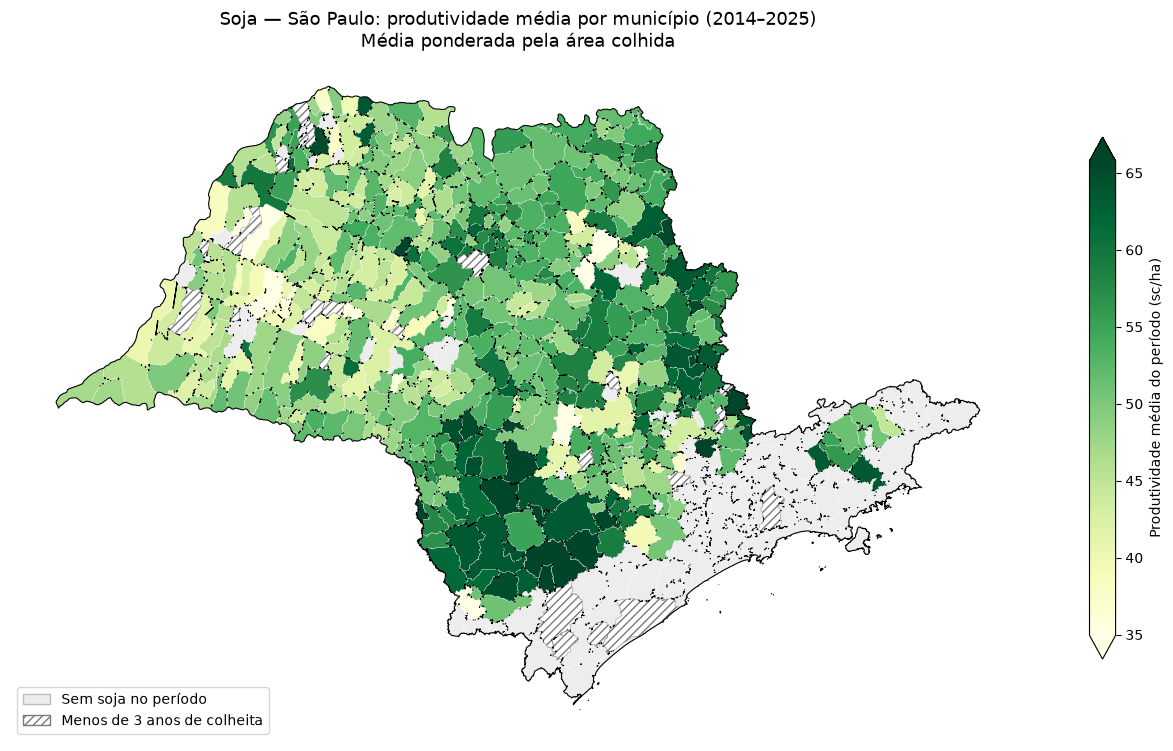

In [42]:
#Mapa

com_soja = mapa[mapa["confiavel"] == True]
pouca_serie = mapa[mapa["confiavel"] == False]
sem_soja = mapa[mapa["rend_medio_sc_ha"].isna()]
 
# Escala cortada nos percentis 2–98 para outliers não "lavarem" as cores
vmin, vmax = np.nanpercentile(com_soja["rend_medio_sc_ha"], [2, 98])
 
fig, ax = plt.subplots(figsize=(13, 9))
 
sem_soja.plot(ax=ax, color="#EDEDED", edgecolor="white", linewidth=0.2)
com_soja.plot(
    ax=ax, column="rend_medio_sc_ha", cmap="YlGn", vmin=vmin, vmax=vmax,
    edgecolor="white", linewidth=0.2, legend=True,
    legend_kwds={"label": "Produtividade média do período (sc/ha)", "shrink": 0.6},
)
if len(pouca_serie):
    pouca_serie.plot(ax=ax, facecolor="none", edgecolor="#7A7A7A",
                     hatch="////", linewidth=0.3)
mun_sp.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8)
 
anos_periodo = f"{base['Ano'].min()}–{base['Ano'].max()}"
ax.set_title(f"Soja — São Paulo: produtividade média por município ({anos_periodo})\n"
             "Média ponderada pela área colhida", fontsize=13)
ax.legend(
    handles=[
        Patch(facecolor="#EDEDED", edgecolor="#BDBDBD", label="Sem soja no período"),
        Patch(facecolor="white", edgecolor="#7A7A7A", hatch="////",
              label=f"Menos de {MIN_ANOS} anos de colheita"),
    ],
    loc="lower left", frameon=True,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()
 

In [43]:
# 5. Destaques (apenas municípios com série confiável)
# ---------------------------------------------------------------------------
cols = ["Municipio", "n_anos", "area_media_ha", "rend_medio_sc_ha", "cv_pct"]
ranking = prod_mun[prod_mun["confiavel"]].sort_values("rend_medio_sc_ha", ascending=False)
 
print("\nTOP 10 — maior produtividade média")
print(ranking[cols].head(10).round(1).to_string(index=False))
print("\nTOP 10 — menor produtividade média")
print(ranking[cols].tail(10).round(1).to_string(index=False))
print("\nTOP 10 — maior área média colhida (principais produtores)")
print(ranking.sort_values("area_media_ha", ascending=False)[cols].head(10)
      .round(1).to_string(index=False))



TOP 10 — maior produtividade média
                   Municipio  n_anos  area_media_ha  rend_medio_sc_ha  cv_pct
           Capão Bonito - SP      12        20875.0              74.2    10.1
        Ribeirão Grande - SP      11         1709.1              72.7     9.0
     São Miguel Arcanjo - SP      12         8450.0              72.6    16.7
                Ubarana - SP      12          300.0              70.8    22.8
                Itatiba - SP       9          130.0              69.7    11.5
               Itatinga - SP      12          975.8              69.3    10.4
               Pratânia - SP       8          193.0              68.5     8.9
Campina do Monte Alegre - SP      12         4000.0              66.5    13.3
      Barão de Antonina - SP      12         2516.7              66.4    13.1
                Socorro - SP      11          877.3              66.3     7.6

TOP 10 — menor produtividade média
                   Municipio  n_anos  area_media_ha  rend_medio_sc_ha 

## Variabilidade: coeficiente de variação por município (estáveis x arriscados)

In [44]:
MIN_ANOS_CV = 8          # mínimo de safras com colheita para entrar na análise
LIMIAR_REPETICAO = 0.5   # >= 50% dos anos com rendimento idêntico ao ano anterior = série suspeita

ano_ref = estadual.index.max()
fator_tec = estadual.loc[ano_ref, "tendencia_kg_ha"] / estadual["tendencia_kg_ha"]
base["rend_ajust_kg_ha"] = base["rendimento_kg_ha"] * base["Ano"].map(fator_tec)

# Valores repetidos ano a ano: na PAM/IBGE alguns municípios repetem a estimativa,
# o que gera CV artificialmente baixo (parece estável, mas é falta de informação)
base = base.sort_values(["Municipio (Código)", "Ano"])
base["rend_repetido"] = base.groupby("Municipio (Código)")["rendimento_kg_ha"].diff().eq(0)

var_mun = (
    base.groupby(["Municipio (Código)", "Municipio"])
    .agg(
        n_anos=("Ano", "nunique"),
        area_media_ha=("area_colhida_ha", "mean"),
        rend_medio_kg_ha=("rend_ajust_kg_ha", "mean"),
        std_kg_ha=("rend_ajust_kg_ha", "std"),
        pior_ano_kg_ha=("rend_ajust_kg_ha", "min"),
        rend_bruto_medio=("rendimento_kg_ha", "mean"),
        std_bruto=("rendimento_kg_ha", "std"),
        n_repetidos=("rend_repetido", "sum"),
    )
    .reset_index()
)

# Média simples aqui (cada safra pesa igual): o CV mede a oscilação ano a ano do município
var_mun["cv_pct"] = var_mun["std_kg_ha"] / var_mun["rend_medio_kg_ha"] * 100
var_mun["cv_bruto_pct"] = var_mun["std_bruto"] / var_mun["rend_bruto_medio"] * 100
var_mun["rend_medio_sc_ha"] = var_mun["rend_medio_kg_ha"] / 60
var_mun["queda_pior_ano_pct"] = (var_mun["pior_ano_kg_ha"] / var_mun["rend_medio_kg_ha"] - 1) * 100
var_mun["pct_repetidos"] = var_mun["n_repetidos"] / (var_mun["n_anos"] - 1)
var_mun["serie_suspeita"] = var_mun["pct_repetidos"] >= LIMIAR_REPETICAO
var_mun["cod_muni"] = var_mun["Municipio (Código)"].astype(int)

# Universo da análise: série longa e não suspeita
analise = var_mun[(var_mun["n_anos"] >= MIN_ANOS_CV) & (~var_mun["serie_suspeita"])].copy()

# Classificação em quadrantes (medianas dos municípios analisados)
med_sc = analise["rend_medio_sc_ha"].median()
med_cv = analise["cv_pct"].median()

alta = analise["rend_medio_sc_ha"] >= med_sc
estavel = analise["cv_pct"] <= med_cv
analise["classe"] = np.select(
    [alta & estavel, alta & ~estavel, ~alta & estavel, ~alta & ~estavel],
    ["Alta e estável", "Alta e arriscada", "Baixa e estável", "Baixa e arriscada"],
    default="",
)

CORES_CLASSE = {
    "Alta e estável": "#58B15D",
    "Alta e arriscada": "#D8A34E",
    "Baixa e estável": "#8AA8CA",
    "Baixa e arriscada": "#9B4141",
}

print("=" * 70)
print("VARIABILIDADE DA PRODUTIVIDADE — CV POR MUNICÍPIO")
print("=" * 70)
print(f"Municípios com soja:                         {len(var_mun)}")
print(f"  - com < {MIN_ANOS_CV} anos (fora da análise):        {(var_mun['n_anos'] < MIN_ANOS_CV).sum()}")
print(f"  - série suspeita (valores repetidos):       {(var_mun['serie_suspeita'] & (var_mun['n_anos'] >= MIN_ANOS_CV)).sum()}")
print(f"Municípios analisados:                       {len(analise)}")
print(f"Mediana de produtividade (ajustada a {ano_ref}): {med_sc:.1f} sc/ha")
print(f"Mediana do CV: {med_cv:.1f}%  (CV bruto, sem tirar tendência: {analise['cv_bruto_pct'].median():.1f}%)")
print()

resumo = analise.groupby("classe").agg(
    municipios=("Municipio", "count"),
    area_media_total_ha=("area_media_ha", "sum"),
    rend_medio_sc_ha=("rend_medio_sc_ha", "median"),
    cv_mediano_pct=("cv_pct", "median"),
    queda_pior_ano_pct=("queda_pior_ano_pct", "median"),
)
resumo["pct_area"] = resumo["area_media_total_ha"] / resumo["area_media_total_ha"].sum() * 100
display(resumo.reindex(CORES_CLASSE.keys()).round(1))


VARIABILIDADE DA PRODUTIVIDADE — CV POR MUNICÍPIO
Municípios com soja:                         514
  - com < 8 anos (fora da análise):        108
  - série suspeita (valores repetidos):       76
Municípios analisados:                       330
Mediana de produtividade (ajustada a 2025): 52.9 sc/ha
Mediana do CV: 18.1%  (CV bruto, sem tirar tendência: 18.6%)



,municipios,area_media_total_ha,rend_medio_sc_ha,cv_mediano_pct,queda_pior_ano_pct,pct_area
classe,,,,,,
Alta e estável,102,489768.2,58.0,14.1,-27.1,49.3
Alta e arriscada,63,202154.6,55.8,20.8,-40.6,20.3
Baixa e estável,63,80595.7,48.9,14.9,-22.5,8.1
Baixa e arriscada,102,221701.1,47.9,23.3,-39.7,22.3


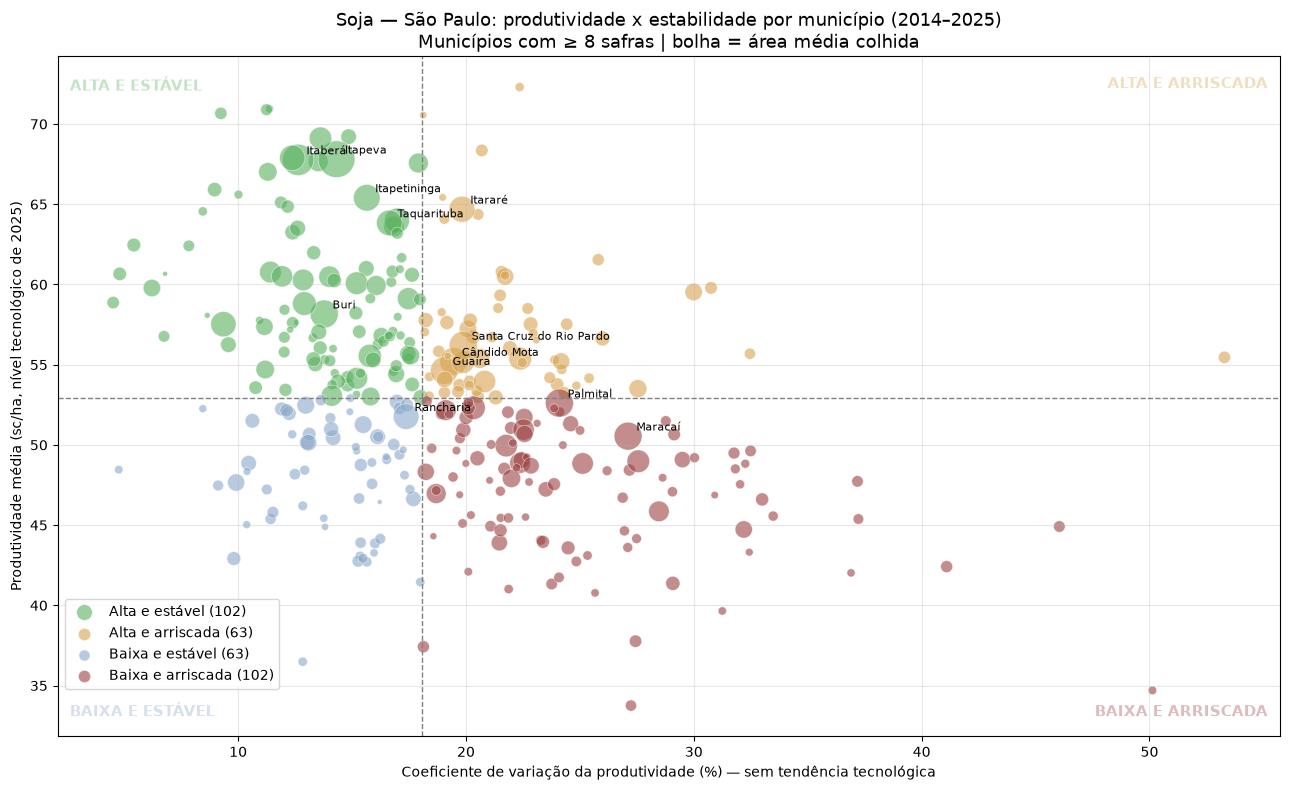

In [45]:
# Gráfico 1: produtividade x CV (dispersão em quadrantes)
# Tamanho da bolha = área média colhida | linhas tracejadas = medianas

N_ROTULOS = 12  # rotula os maiores produtores

fig, ax = plt.subplots(figsize=(13, 8))

for classe, cor in CORES_CLASSE.items():
    d = analise[analise["classe"] == classe]
    ax.scatter(
        d["cv_pct"], d["rend_medio_sc_ha"],
        s=np.sqrt(d["area_media_ha"]) * 2.5, c=cor, alpha=0.6,
        edgecolors="white", linewidths=0.5, label=f"{classe} ({len(d)})",
    )

ax.axvline(med_cv, color="gray", ls="--", lw=1)
ax.axhline(med_sc, color="gray", ls="--", lw=1)

for _, r in analise.nlargest(N_ROTULOS, "area_media_ha").iterrows():
    ax.annotate(r["Municipio"].replace(" - SP", ""), (r["cv_pct"], r["rend_medio_sc_ha"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# Nome dos quadrantes nos cantos
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
kw = dict(fontsize=11, fontweight="bold", alpha=0.35)
ax.text(x0 + 0.01 * (x1 - x0), y1 - 0.03 * (y1 - y0), "ALTA E ESTÁVEL", color=CORES_CLASSE["Alta e estável"], va="top", **kw)
ax.text(x1 - 0.01 * (x1 - x0), y1 - 0.03 * (y1 - y0), "ALTA E ARRISCADA", color=CORES_CLASSE["Alta e arriscada"], va="top", ha="right", **kw)
ax.text(x0 + 0.01 * (x1 - x0), y0 + 0.03 * (y1 - y0), "BAIXA E ESTÁVEL", color=CORES_CLASSE["Baixa e estável"], **kw)
ax.text(x1 - 0.01 * (x1 - x0), y0 + 0.03 * (y1 - y0), "BAIXA E ARRISCADA", color=CORES_CLASSE["Baixa e arriscada"], ha="right", **kw)

ax.set_xlabel("Coeficiente de variação da produtividade (%) — sem tendência tecnológica")
ax.set_ylabel(f"Produtividade média (sc/ha, nível tecnológico de {ano_ref})")
ax.set_title(f"Soja — São Paulo: produtividade x estabilidade por município ({anos_periodo})\n"
             f"Municípios com ≥ {MIN_ANOS_CV} safras | bolha = área média colhida", fontsize=13)
ax.legend(loc="lower left", bbox_to_anchor=(0, 0.06), frameon=True, markerscale=0.6)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


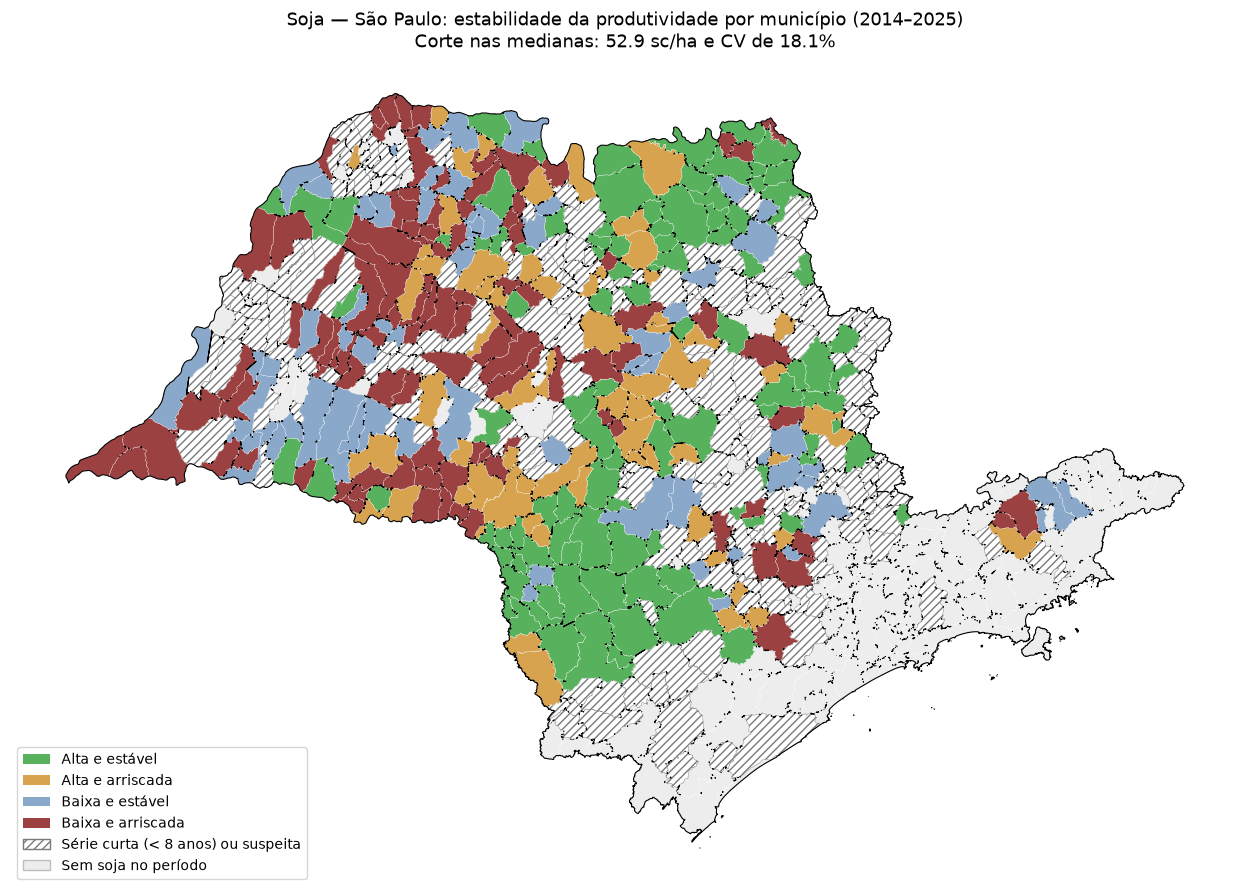

In [46]:
# Gráfico 2: mapa das classes de risco

mapa_cv = mun_sp.merge(analise[["cod_muni", "classe", "cv_pct"]], on="cod_muni", how="left")
mapa_cv = mapa_cv.merge(var_mun[["cod_muni", "n_anos"]], on="cod_muni", how="left")

fora_analise = mapa_cv[mapa_cv["classe"].isna() & mapa_cv["n_anos"].notna()]   # tem soja, mas série curta/suspeita
sem_soja_cv = mapa_cv[mapa_cv["n_anos"].isna()]

fig, ax = plt.subplots(figsize=(13, 9))
sem_soja_cv.plot(ax=ax, color="#EDEDED", edgecolor="white", linewidth=0.2)
fora_analise.plot(ax=ax, facecolor="white", edgecolor="#7A7A7A", hatch="////", linewidth=0.3)
for classe, cor in CORES_CLASSE.items():
    d = mapa_cv[mapa_cv["classe"] == classe]
    if len(d):
        d.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.2)
mun_sp.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.legend(
    handles=[Patch(facecolor=cor, label=classe) for classe, cor in CORES_CLASSE.items()]
    + [
        Patch(facecolor="white", edgecolor="#7A7A7A", hatch="////",
              label=f"Série curta (< {MIN_ANOS_CV} anos) ou suspeita"),
        Patch(facecolor="#EDEDED", edgecolor="#BDBDBD", label="Sem soja no período"),
    ],
    loc="lower left", frameon=True,
)
ax.set_title(f"Soja — São Paulo: estabilidade da produtividade por município ({anos_periodo})\n"
             f"Corte nas medianas: {med_sc:.1f} sc/ha e CV de {med_cv:.1f}%", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()


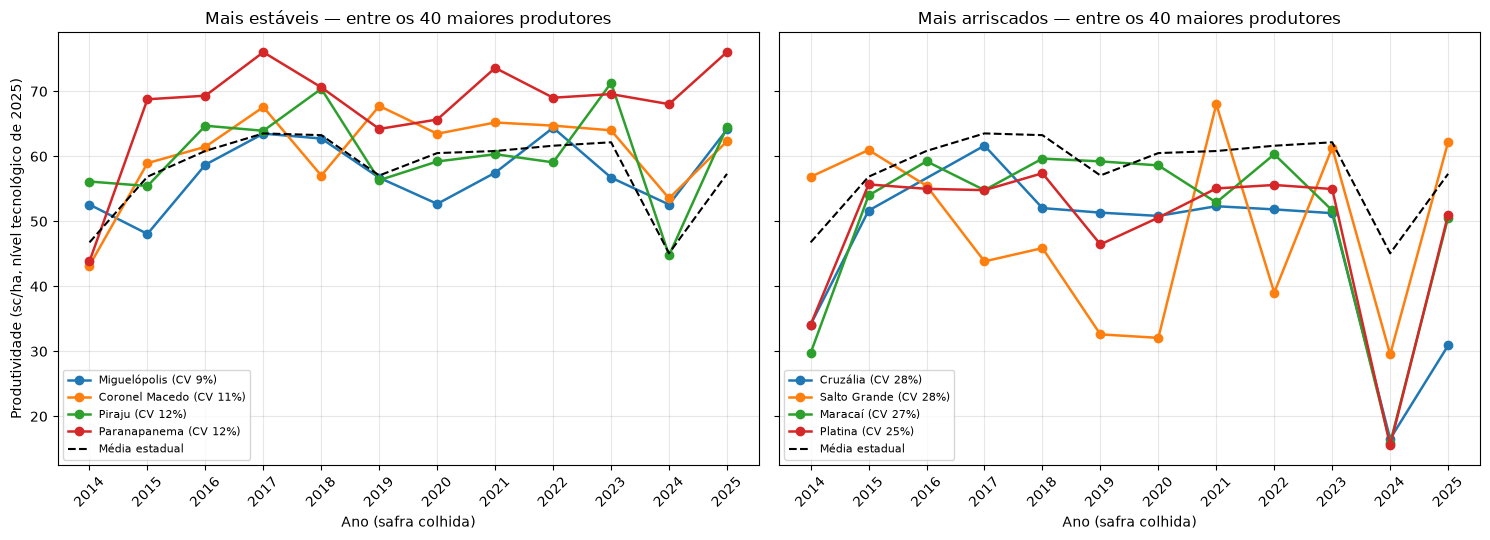

In [47]:
# Gráfico 3: séries dos mais estáveis x mais arriscados entre os grandes produtores
# (mostra na prática o que um CV baixo ou alto significa)

TOP_PRODUTORES = 40   # universo: os N municípios com maior área média
N_SERIES = 4

grandes = analise.nlargest(TOP_PRODUTORES, "area_media_ha")
estaveis = grandes.nsmallest(N_SERIES, "cv_pct")
arriscados = grandes.nlargest(N_SERIES, "cv_pct")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, grupo, titulo in [
    (axes[0], estaveis, "Mais estáveis"),
    (axes[1], arriscados, "Mais arriscados"),
]:
    for _, r in grupo.iterrows():
        s = base[base["Municipio (Código)"] == r["Municipio (Código)"]].sort_values("Ano")
        ax.plot(s["Ano"], s["rend_ajust_kg_ha"] / 60, "o-", lw=1.8,
                label=f"{r['Municipio'].replace(' - SP', '')} (CV {r['cv_pct']:.0f}%)")
    ax.plot(estadual.index, estadual["rend_kg_ha"] * fator_tec / 60, color="black",
            ls="--", lw=1.5, label="Média estadual")
    ax.set_title(f"{titulo} — entre os {TOP_PRODUTORES} maiores produtores")
    ax.set_xlabel("Ano (safra colhida)")
    ax.set_xticks(estadual.index)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel(f"Produtividade (sc/ha, nível tecnológico de {ano_ref})")
plt.tight_layout()
plt.show()


In [48]:
# Rankings (só municípios com área relevante, para não destacar quem planta 30 ha)

AREA_MIN_RANKING = 1000  # ha de área média colhida

cols = ["Municipio", "n_anos", "area_media_ha", "rend_medio_sc_ha", "cv_pct",
        "cv_bruto_pct", "queda_pior_ano_pct", "classe"]
relevantes = analise[analise["area_media_ha"] >= AREA_MIN_RANKING]

print(f"Municípios com área média >= {AREA_MIN_RANKING} ha: {len(relevantes)}")
print("\nTOP 10 — MAIS ESTÁVEIS (menor CV)")
print(relevantes.nsmallest(10, "cv_pct")[cols].round(1).to_string(index=False))
print("\nTOP 10 — MAIS ARRISCADOS (maior CV)")
print(relevantes.nlargest(10, "cv_pct")[cols].round(1).to_string(index=False))

print("\nSéries suspeitas (valores repetidos) — conferir antes de usar no modelo")
print(var_mun[var_mun["serie_suspeita"]].nlargest(10, "area_media_ha")
      [["Municipio", "n_anos", "area_media_ha", "n_repetidos", "cv_bruto_pct"]]
      .round(1).to_string(index=False))


Municípios com área média >= 1000 ha: 150

TOP 10 — MAIS ESTÁVEIS (menor CV)
          Municipio  n_anos  area_media_ha  rend_medio_sc_ha  cv_pct  cv_bruto_pct  queda_pior_ano_pct          classe
        Franca - SP      12         1016.7              58.9     4.5           6.6                -4.6  Alta e estável
       Itapira - SP      10         1399.5              60.7     4.8           6.6                -9.7  Alta e estável
       Itapura - SP      12         1499.1              62.5     5.4           7.1               -15.1  Alta e estável
     Nuporanga - SP      12         3981.7              59.8     6.2           7.4                -7.2  Alta e estável
         Iaras - SP      12         1808.1              65.9     9.0          10.7               -14.8  Alta e estável
  Miguelópolis - SP      12        17582.3              57.5     9.4          11.3               -16.5  Alta e estável
     Riolândia - SP      12         2556.2              56.2     9.6          10.4        